# Cinema Ticket Forecasting: EDA Notebook (rebuild)

**Goal of this notebook:** understand the data *before* modelling. It only loads, checks and plots. It does **not** write any new CSV.

**The big lesson from the first attempt:** `isna()` only finds empty *cells* in rows that exist. The real problems are usually **rows that are missing**, **keys that do not match** (movie titles!), and **a test set that is built differently from train**.

| Stage | Question we answer | Main graphic |
|---|---|---|
| 0 | What is in each file, and which time period does each cover? | timeline |
| 1 | How is the test question built? | window structure |
| 2 | Do the movie titles match across files? | before/after bars |
| 3 | Which rows are missing? | gap raster |
| 4 | What drives `total_ticket`? | trend, weekday, holiday, format |
| 5 | How do movies behave over time, and how big is the cold-start problem? | age curve, scatter |
| 6 | Is movie metadata useful and how complete is it? | coverage, genre, rating |
| 7 | Do city and ticket price matter? | price vs. tickets |

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})

DATA = "dataset/"        # the 7 CSVs from the zip
EXT  = "external_data/"  # acquisition_audit.csv, missing_movies_metadata.csv

## Stage 0: Load raw files and look at what we have

**What to do:** read every file, check `shape`, `dtypes`, and empty cells.

**Why:** it is the cheapest sanity check. But remember: **a clean `isna()` does not mean clean data.** It cannot see rows that should exist but do not.

**What to look for:** which files share the same columns, and which time period each file covers.

In [2]:
train     = pd.read_csv(DATA + "train.csv",           parse_dates=["date_show"])
test_hist = pd.read_csv(DATA + "test_history.csv",    parse_dates=["date_show"])
test      = pd.read_csv(DATA + "test.csv",            parse_dates=["date_show"])
movies    = pd.read_csv(DATA + "movies.csv")
holidays  = pd.read_csv(DATA + "holidays.csv",        parse_dates=["date"])
prices    = pd.read_csv(DATA + "ticket_prices.csv")
sample_sub= pd.read_csv(DATA + "sample_submission.csv")
ext_meta  = pd.read_csv(EXT  + "missing_movies_metadata.csv")
audit     = pd.read_csv(EXT  + "acquisition_audit.csv")

tables = {"train": train, "test_history": test_hist, "test": test, "movies": movies,
          "holidays": holidays, "ticket_prices": prices, "sample_submission": sample_sub,
          "ext_meta": ext_meta, "ext_audit": audit}

overview = pd.DataFrame({
    "rows":          {k: len(v) for k, v in tables.items()},
    "columns":       {k: v.shape[1] for k, v in tables.items()},
    "empty_cells":   {k: int(v.isna().sum().sum()) for k, v in tables.items()},
})
overview

,rows,columns,empty_cells
train,138959,7,0
test_history,32323,7,0
test,72611,5,0
movies,397,7,3
holidays,366,5,348
ticket_prices,207,3,0
sample_submission,72611,2,0
ext_meta,20,16,22
ext_audit,20,2,0


In [3]:
# Which columns does each table have?
for name, df in tables.items():
    print(f"{name:18s}", list(df.columns))

train              ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
test_history       ['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
test               ['id', 'movie_title', 'cinema_ids', 'city_name', 'date_show']
movies             ['original_title', 'age_rating', 'genre', 'producer', 'director', 'writer', 'casts']
holidays           ['date', 'day_tipe', 'holiday_tipe', 'holiday_name', 'holiday_tier']
ticket_prices      ['city_name', 'ceil', 'price_day']
sample_submission  ['id', 'total_ticket']
ext_meta           ['original_title', 'age_rating', 'genre', 'producer', 'director', 'writer', 'casts', 'overview', 'popularity', 'runtime', 'original_language', 'release_year', 'released', 'imdb_id', 'imdb_rating', 'tmdb_id']
ext_audit          ['test_title', 'result']


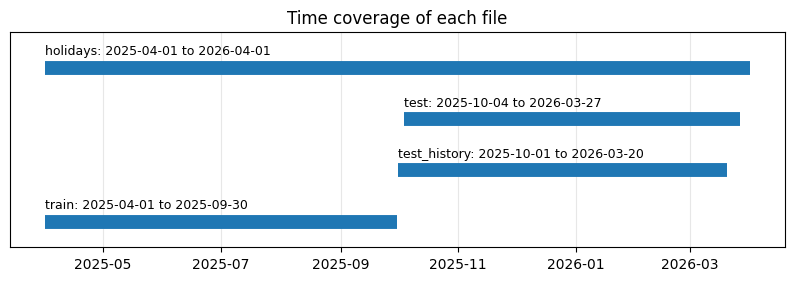

In [4]:
# Graphic: which period does each file cover?
spans = {
    "train":        (train.date_show.min(),     train.date_show.max()),
    "test_history": (test_hist.date_show.min(), test_hist.date_show.max()),
    "test":         (test.date_show.min(),      test.date_show.max()),
    "holidays":     (holidays.date.min(),       holidays.date.max()),
}
fig, ax = plt.subplots(figsize=(10, 2.8))
for i, (name, (a, b)) in enumerate(spans.items()):
    ax.hlines(i, a, b, linewidth=10)
    ax.text(a, i + 0.25, f"{name}: {a.date()} to {b.date()}", fontsize=9)
ax.set_yticks([]); ax.set_ylim(-0.5, len(spans) - 0.3)
ax.set_title("Time coverage of each file")
plt.show()

**What you should see:** train ends 30 Sep 2025, but test starts in Oct 2025 and runs to Mar 2026. So **we forecast a different season than we trained on** (Dec holidays, Imlek, Idulfitri 2026). Train alone cannot teach those periods, and `holidays.csv` is the only file that knows about them.

## Stage 1: How is the test question built?

**What to do:** look at test **per (cinema, movie) pair**: how many days to predict, and how much history we get.

**Why:** the way the test is built tells us what a *good validation* looks like later. If we do not copy this structure, our local score will lie to us.

In [5]:
keys = ["cinema_ids", "movie_title"]

pair_test = test.groupby(keys).date_show.agg(start="min", end="max", n_days="count")
pair_hist = test_hist.groupby(keys).date_show.agg(h_start="min", h_end="max", h_days="count")
pairs = pair_test.join(pair_hist, how="left")
pairs["h_days"] = pairs["h_days"].fillna(0).astype(int)
pairs["days_between"] = (pairs["start"] - pairs["h_end"]).dt.days

print("pairs in test:", len(pairs))
print("\ndays to predict per pair:\n", pairs.n_days.value_counts().to_string())
print("\nhistory days per pair:\n",    pairs.h_days.value_counts().sort_index().to_string())
print("\nday gap between end of history and start of test:\n", pairs.days_between.value_counts().to_string())

pairs in test: 10373

days to predict per pair:
 n_days
7    10373

history days per pair:
 h_days
1     189
2     730
3    9454

day gap between end of history and start of test:
 days_between
1    10373


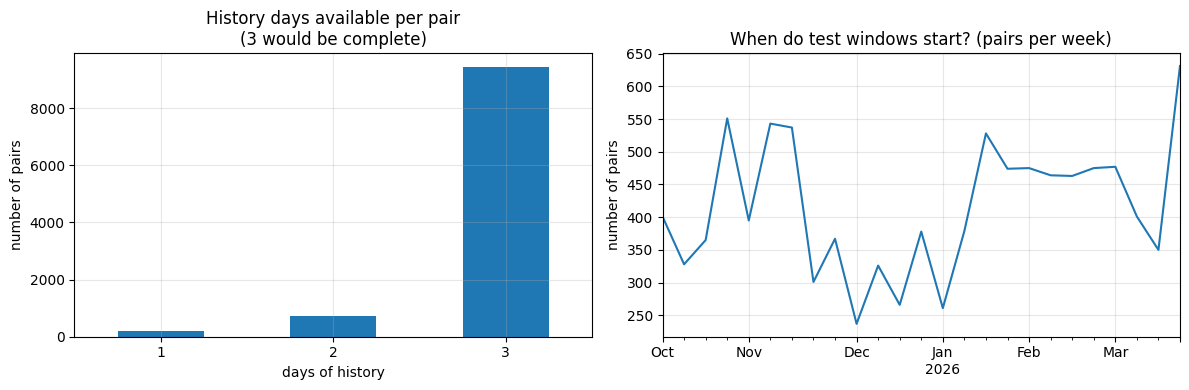

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pairs.h_days.value_counts().sort_index().plot.bar(ax=axes[0], rot=0)
axes[0].set_title("History days available per pair\n(3 would be complete)")
axes[0].set_xlabel("days of history"); axes[0].set_ylabel("number of pairs")

pairs.set_index("start").resample("W").size().plot(ax=axes[1])
axes[1].set_title("When do test windows start? (pairs per week)")
axes[1].set_xlabel(""); axes[1].set_ylabel("number of pairs")
plt.tight_layout(); plt.show()

**What you should see:** every pair has **exactly 7 test days**, starting the day **right after up to 3 history days**. Each pair has just **one window**, and windows are spread across Oct to Mar.

**Lessons**
- `test_history` is **not** a continuous record. It is a short 3-day look at each pair, right before its test window.
- The strongest clue for a pair's next 7 days is probably its own last 3 days. Later we will test this idea on train.
- `occupation_rate` and `total_show` exist in train and history but **not in test**. We can only use them as *past* information (from history), never for the days we predict.
- Some pairs have fewer than 3 history days. That is already a hint of missing rows (Stage 3).

## Stage 2: Do movie titles match across files?

**What to do:** build a *clean title* and compare it with the raw title.

**Why:** `movies.csv` has one row per movie, but the ticket files have rows like `HOPPERS (IMAX 2D)` or `AVATAR: FIRE AND ASH (3D)`. A plain join fails **silently**: no error, just empty features. This is another thing `isna()` cannot warn you about until after the join.

**Rule we follow:**
- `movie_title` (original) stays the grain of the data, because the test rows are at that level.
- `movie_base` (clean title) is used only to **join movie information** and to build movie-level views.
- `format` (REGULAR, 3D, IMAX 2D, IMAX 3D) is its own feature.

In [7]:
def base_title(s):
    s = str(s).upper().strip()
    s = re.sub(r"\s*\((?:IMAX\s*)?(?:2D|3D)\)\s*$", "", s)   # remove (3D) / (IMAX 2D) at the end
    s = re.sub(r"[^A-Z0-9 ]", " ", s)                          # remove punctuation like : - ' !
    return re.sub(r"\s+", " ", s).strip()                      # collapse spaces

def screen_format(s):
    m = re.search(r"\((IMAX\s*2D|IMAX\s*3D|2D|3D)\)\s*$", str(s).upper().strip())
    return re.sub(r"\s+", " ", m.group(1)) if m else "REGULAR"

for df in (train, test_hist, test):
    df["movie_base"] = df["movie_title"].map(base_title)
    df["format"]     = df["movie_title"].map(screen_format)

movies["movie_base"]   = movies["original_title"].map(base_title)
ext_meta["movie_base"] = ext_meta["original_title"].map(base_title)

# quick test of the cleaner
for t in ["HOPPERS (IMAX 2D)", "AVATAR: FIRE AND ASH (3D)", "MISSION: IMPOSSIBLE - THE FINAL RECKONING (IMAX 2D) "]:
    print(f"{t!r:62} -> {base_title(t)!r}, {screen_format(t)}")

'HOPPERS (IMAX 2D)'                                            -> 'HOPPERS', IMAX 2D
'AVATAR: FIRE AND ASH (3D)'                                    -> 'AVATAR FIRE AND ASH', 3D
'MISSION: IMPOSSIBLE - THE FINAL RECKONING (IMAX 2D) '         -> 'MISSION IMPOSSIBLE THE FINAL RECKONING', IMAX 2D


,1) raw title vs movies.csv,2) clean title vs movies.csv,3) clean title vs movies + external
table,,,
train,28,0,0
test_history,23,0,0
test,20,0,0


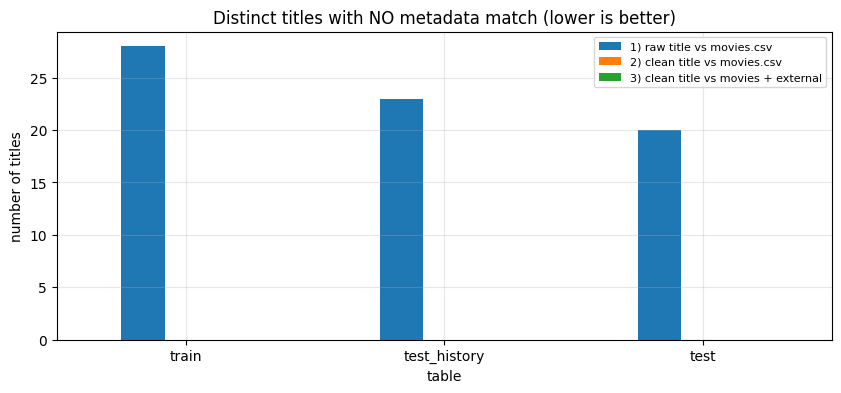

In [8]:
# How many distinct titles fail to match, under 3 different approaches?
raw_keys   = set(movies.original_title)
base_keys  = set(movies.movie_base)
ext_keys   = set(ext_meta.movie_base)

rows = []
for name, df in {"train": train, "test_history": test_hist, "test": test}.items():
    t = df[["movie_title", "movie_base"]].drop_duplicates()
    rows.append({
        "table": name,
        "1) raw title vs movies.csv":          int((~t.movie_title.isin(raw_keys)).sum()),
        "2) clean title vs movies.csv":        int((~t.movie_base.isin(base_keys)).sum()),
        "3) clean title vs movies + external": int((~t.movie_base.isin(base_keys | ext_keys)).sum()),
    })
unmatched = pd.DataFrame(rows).set_index("table")
display(unmatched)

ax = unmatched.plot.bar(rot=0, figsize=(10, 4))
ax.set_title("Distinct titles with NO metadata match (lower is better)")
ax.set_ylabel("number of titles"); ax.legend(fontsize=8)
plt.show()

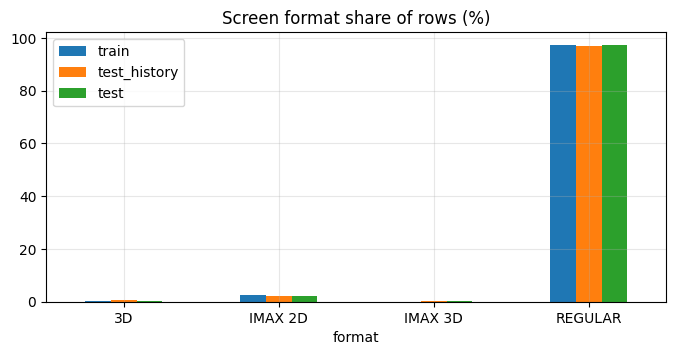

train: 4.5% of rows share cinema + clean title + date with another format row
test: 4.7% of rows share cinema + clean title + date with another format row


In [9]:
# Format mix and the "same movie, same cinema, same day" situation
fmt_share = pd.DataFrame({n: d["format"].value_counts(normalize=True) for n, d in
                          {"train": train, "test_history": test_hist, "test": test}.items()}).fillna(0) * 100
ax = fmt_share.plot.bar(rot=0, figsize=(8, 3.5))
ax.set_title("Screen format share of rows (%)"); plt.show()

for name, df in {"train": train, "test": test}.items():
    dup = df.duplicated(["cinema_ids", "movie_base", "date_show"], keep=False).mean() * 100
    print(f"{name}: {dup:.1f}% of rows share cinema + clean title + date with another format row")

**What you should see:** with the raw title, 20 to 28 titles per file have no match. With the clean title, **zero** are unmatched, and bar 3 is no better than bar 2.

**The surprise:** `movies.csv` already describes every movie once the titles are cleaned. The 15 movies that `missing_movies_metadata.csv` was made for were never really missing. Their titles just carried `(3D)` / `(IMAX 2D)` or punctuation (`AVATAR: FIRE AND ASH` vs `AVATAR FIRE AND ASH`). That is exactly what `acquisition_audit.csv` says ("normalized/deduplicated"). We confirmed it ourselves with the table above.

**Lessons**
- Always count *unmatched keys* before and after every join. This is the check that replaces "missing values look fine".
- About 5% of rows are the **same movie in two formats on the same day in the same cinema**. They are separate rows with separate targets in test, so we **do not merge them**. We only keep the format as a feature.

## Stage 3: Which rows are missing?

**What to do:** for each (cinema, movie) pair, compare the days that *exist* with the days between its first and last date.

**Why:** a row is only written when something was sold. We never see `total_ticket = 0`. So a missing day can mean **zero tickets**, not "unknown". If we model only the rows that exist, we learn from a **biased sample** (only days with sales) and will predict too high.

**What to look for:** how big the gaps are, whether they are random, and whether **test** has the same gaps.

In [10]:
g = train.groupby(keys).date_show.agg(first_day="min", last_day="max", n_rows="count")
g["span_days"]    = (g["last_day"] - g["first_day"]).dt.days + 1
g["missing_days"] = g["span_days"] - g["n_rows"]

print("pairs in train:                    ", len(g))
print("pairs with at least one gap:       ", int((g.missing_days > 0).sum()))
print("missing days inside run windows:   ", int(g.missing_days.sum()))
print(f"share of all in-window days missing: {g.missing_days.sum() / g.span_days.sum():.1%}")
print("smallest total_ticket in train:    ", train.total_ticket.min(), "(zero never appears)")
print("test pairs with gaps:              ", int(((pairs['end'] - pairs['start']).dt.days + 1 - pairs['n_days']).sum()), "(test is complete)")

pairs in train:                     13041
pairs with at least one gap:        3638
missing days inside run windows:    20386
share of all in-window days missing: 12.8%
smallest total_ticket in train:     1 (zero never appears)
test pairs with gaps:               0 (test is complete)


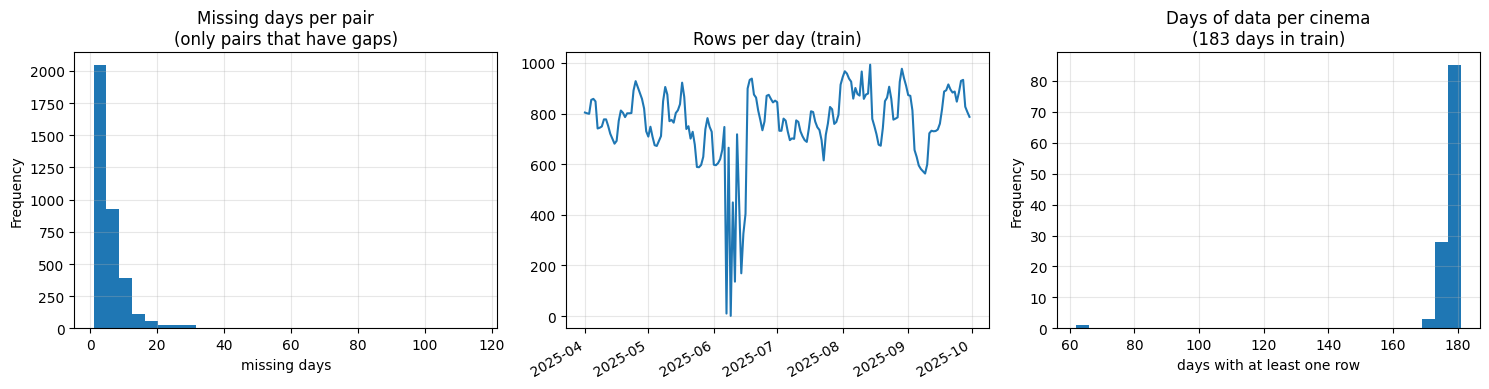

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

g.loc[g.missing_days > 0, "missing_days"].plot.hist(bins=30, ax=axes[0])
axes[0].set_title("Missing days per pair\n(only pairs that have gaps)"); axes[0].set_xlabel("missing days")

train.groupby("date_show").size().plot(ax=axes[1])
axes[1].set_title("Rows per day (train)"); axes[1].set_xlabel("")

train.groupby("cinema_ids").date_show.nunique().plot.hist(bins=30, ax=axes[2])
axes[2].set_title("Days of data per cinema\n(183 days in train)"); axes[2].set_xlabel("days with at least one row")
plt.tight_layout(); plt.show()

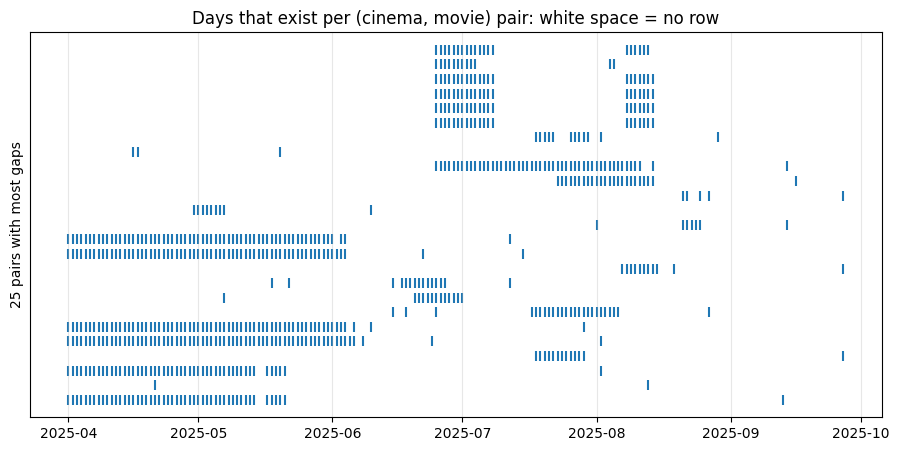

In [12]:
# Picture of the gaps: one line per pair, one tick per day that EXISTS. White space = missing day.
worst = g[(g.span_days >= 30) & (g.missing_days > 0)].sort_values("missing_days", ascending=False).head(25)
ylab  = {k: i for i, k in enumerate(worst.index)}
sub   = train[[k in ylab for k in zip(train.cinema_ids, train.movie_title)]]
ys    = [ylab[k] for k in zip(sub.cinema_ids, sub.movie_title)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(sub.date_show, ys, marker="|", s=60)
ax.set_yticks([]); ax.set_ylabel("25 pairs with most gaps")
ax.set_title("Days that exist per (cinema, movie) pair: white space = no row")
plt.show()

In [13]:
# Same check on test_history: how many pairs have fewer than 3 history days?
print(pairs.h_days.value_counts(normalize=True).sort_index().mul(100).round(1).rename("% of test pairs"))

h_days
1     1.8
2     7.0
3    91.1
Name: % of test pairs, dtype: float64


**What you should see:** about 1 in 8 days inside a movie's run has no row. Gaps are common in long runs: most pairs with 30+ days of life have at least one. The raster (these are the 25 *worst* pairs, so they are not typical) shows that gaps are mostly **long blocks**: a pair runs, disappears for weeks, then returns for a stray day or two. They are not random single missing days. Test, by contrast, is **fully complete: exactly 7 days for every pair**, and 9% of pairs have fewer than 3 history days (the history file has gaps too).

**Lessons**
- Train is **sparse** (days with no sales are absent), test is **dense** (every day must be predicted). They are built differently.
- A long block of absence usually means "not screened" (the movie left that cinema), while a lone missing day inside a busy run is more suspicious. Stray days far from a run also **stretch the span**, so the 12.8% figure mixes both cases. A sharper check is to measure gaps *only inside the main run*.
- Because zero never appears in train, a missing day most likely means **no tickets sold** (not screened, or sold out of showtimes). We cannot prove it from the data. This is an assumption to **test later on validation**: compare "leave gaps" with "fill gaps with 0".
- Rows per day grow as more cinemas join (see the middle plot), so totals over time mix "more demand" with "more cinemas". Prefer *per-row* averages when comparing days.

## Stage 4: What drives `total_ticket`?

**What to do:** look at the target on its own, then against time, weekday, holidays, screen format and number of shows.

**Why:** these plots tell us which features are worth building and what shape the target has (very skewed numbers usually need a log transform).

All merges below are **temporary, in memory, for plotting only**.

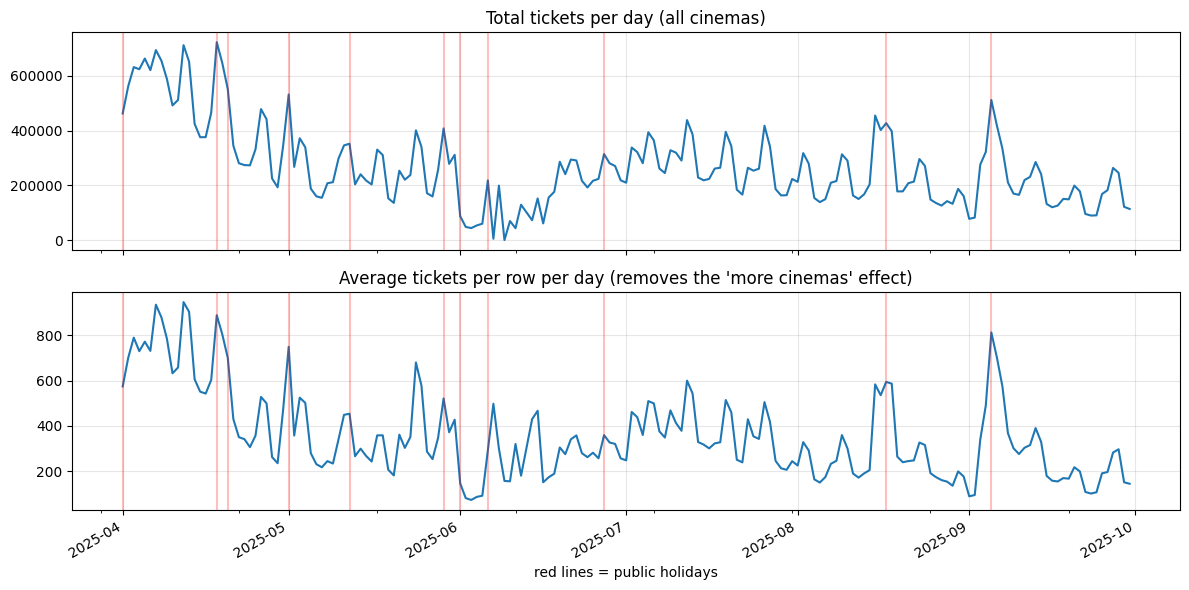

In [14]:
# Temporary join with the holiday calendar (many rows -> one row per date)
tr = train.merge(holidays, left_on="date_show", right_on="date", how="left", validate="m:1")
assert len(tr) == len(train) and tr.day_tipe.notna().all(), "holiday join changed rows or left blanks"

daily = tr.groupby("date_show").agg(total=("total_ticket", "sum"), rows=("total_ticket", "size"))
daily["per_row"] = daily.total / daily.rows
hol_days = holidays.loc[(holidays.holiday_tipe == "holiday") & holidays.date.between(train.date_show.min(), train.date_show.max()), "date"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily.total.plot(ax=axes[0]);   axes[0].set_title("Total tickets per day (all cinemas)")
daily.per_row.plot(ax=axes[1]); axes[1].set_title("Average tickets per row per day (removes the 'more cinemas' effect)")
for ax in axes:
    for h in hol_days: ax.axvline(h, color="red", alpha=0.25)
axes[1].set_xlabel("red lines = public holidays")
plt.tight_layout(); plt.show()

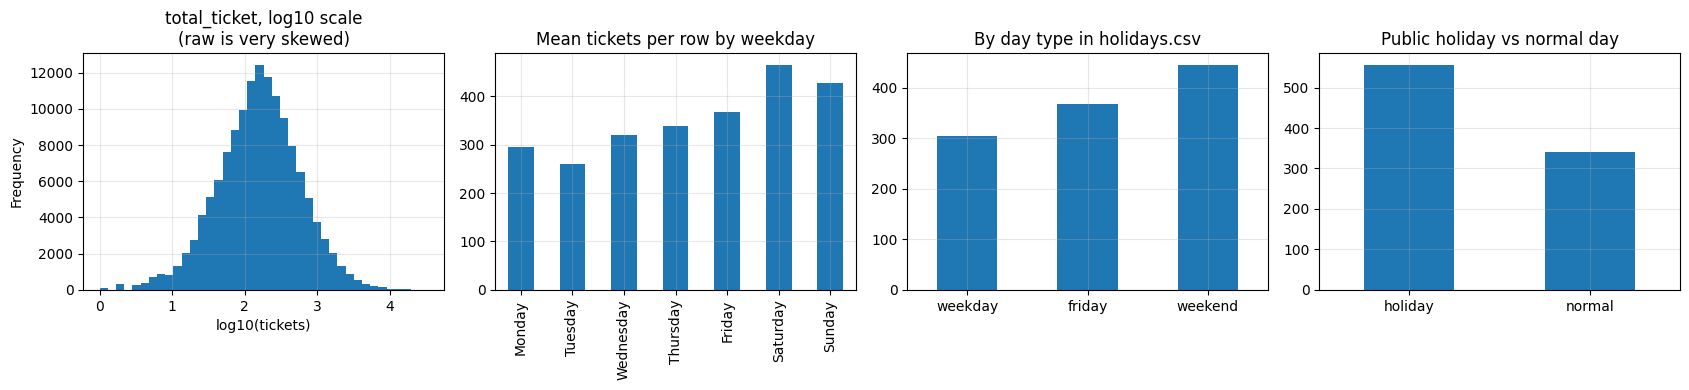

holiday days in train: 11 | in test period: 7


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

np.log10(tr.total_ticket).plot.hist(bins=40, ax=axes[0])
axes[0].set_title("total_ticket, log10 scale\n(raw is very skewed)"); axes[0].set_xlabel("log10(tickets)")

dow = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
tr.groupby(tr.date_show.dt.day_name()).total_ticket.mean().reindex(dow).plot.bar(ax=axes[1])
axes[1].set_title("Mean tickets per row by weekday"); axes[1].set_xlabel("")

tr.groupby("day_tipe").total_ticket.mean().reindex(["weekday", "friday", "weekend"]).plot.bar(ax=axes[2], rot=0)
axes[2].set_title("By day type in holidays.csv"); axes[2].set_xlabel("")

tr.groupby("holiday_tipe").total_ticket.mean().plot.bar(ax=axes[3], rot=0)
axes[3].set_title("Public holiday vs normal day"); axes[3].set_xlabel("")
plt.tight_layout(); plt.show()

print("holiday days in train:", int((tr.drop_duplicates('date_show').holiday_tipe == 'holiday').sum()), "| in test period:",
      int(holidays.loc[holidays.date.between(test.date_show.min(), test.date_show.max()), 'holiday_tipe'].eq('holiday').sum()))

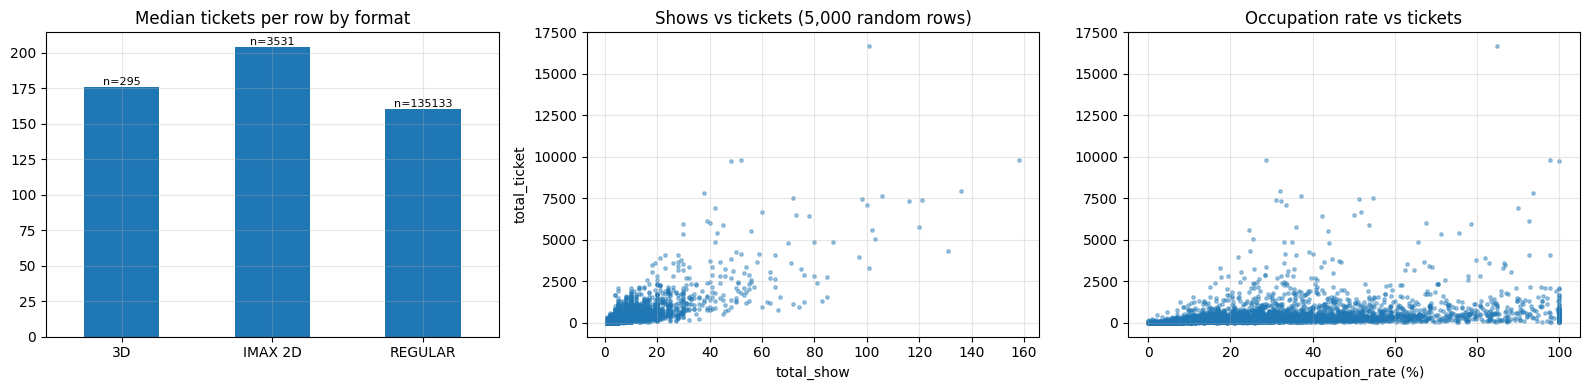

correlation total_show vs total_ticket: 0.786


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

fmt = tr.groupby("format").total_ticket.agg(median="median", n="size")
fmt["median"].plot.bar(ax=axes[0], rot=0)
for i, (m, n) in enumerate(zip(fmt["median"], fmt["n"])): axes[0].text(i, m, f"n={n}", ha="center", va="bottom", fontsize=8)
axes[0].set_title("Median tickets per row by format"); axes[0].set_xlabel("")

s = tr.sample(5000, random_state=0)
axes[1].scatter(s.total_show, s.total_ticket, s=6, alpha=0.4)
axes[1].set_title("Shows vs tickets (5,000 random rows)"); axes[1].set_xlabel("total_show"); axes[1].set_ylabel("total_ticket")

axes[2].scatter(s.occupation_rate, s.total_ticket, s=6, alpha=0.4)
axes[2].set_title("Occupation rate vs tickets"); axes[2].set_xlabel("occupation_rate (%)")
plt.tight_layout(); plt.show()
print("correlation total_show vs total_ticket:", round(tr.total_show.corr(tr.total_ticket), 3))

**What you should see:** a long right tail (many small days, a few huge ones). Saturday and Sunday average roughly 430 to 465 tickets per row against about 260 to 340 on Monday to Thursday, with Friday in between. Public holidays average about 560 against about 340 on normal days. For format, the **median** is higher for IMAX 2D (about 204) and 3D (about 176) than REGULAR (about 160), but the **mean** of REGULAR is higher because it has a few very big days, so be careful which number you quote. `total_show` and tickets correlate at about 0.79.

**Lessons**
- Model **log(tickets)** or a count-aware loss, not raw tickets.
- Calendar features (weekday, `day_tipe`, holiday flag, days to/from a holiday) are cheap and useful. The **test period has holidays train never saw** (Natal, Tahun Baru, Imlek, Nyepi, Idulfitri 2026), so a flag like "is holiday" generalises while "which holiday" does not.
- `total_show` is very predictive but **not available in test**. It is only a clue from history. Never feed it in as a same-day feature.

## Stage 5: Movie life cycle and the cold-start problem

**What to do:** (a) see how tickets change with a movie's age, (b) measure how much of test involves things train has never seen, (c) imitate the test setup on train ("first 3 days" to "next 7 days").

**Why:** most test movies are new releases. If tickets decay with movie age, and the first days predict the next days, then history is our best feature.

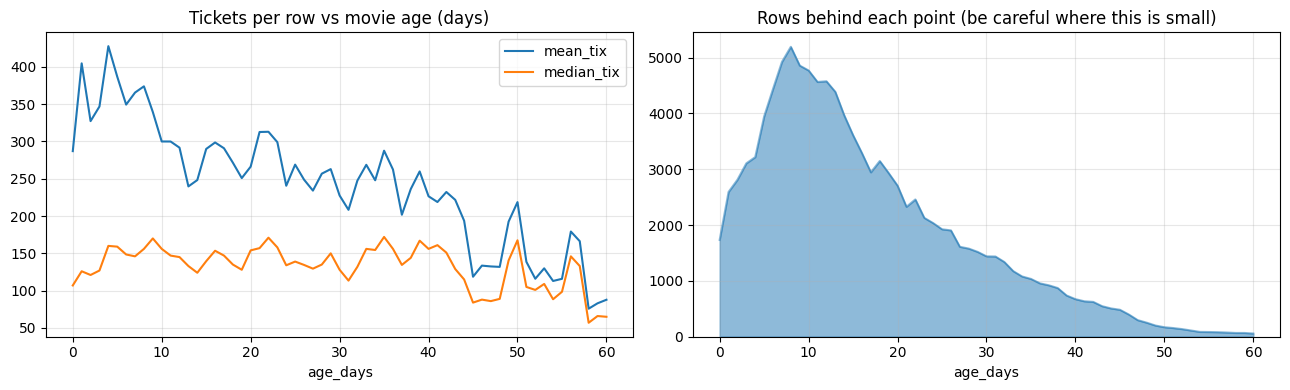

movies used: 184


In [17]:
# (a) Tickets by days since the movie first appeared in train.
#     We skip movies already running on day 1 of the data, because their real start is unknown.
first_seen = train.groupby("movie_base").date_show.min().rename("first_seen")
t = train.join(first_seen, on="movie_base")
t = t[t.first_seen >= train.date_show.min() + pd.Timedelta(days=14)].copy()
t["age_days"] = (t.date_show - t.first_seen).dt.days

curve = t[t.age_days <= 60].groupby("age_days").total_ticket.agg(mean_tix="mean", median_tix="median", n_rows="size")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
curve[["mean_tix", "median_tix"]].plot(ax=axes[0]); axes[0].set_title("Tickets per row vs movie age (days)")
curve.n_rows.plot.area(ax=axes[1], alpha=0.5);      axes[1].set_title("Rows behind each point (be careful where this is small)")
plt.tight_layout(); plt.show()
print("movies used:", t.movie_base.nunique())

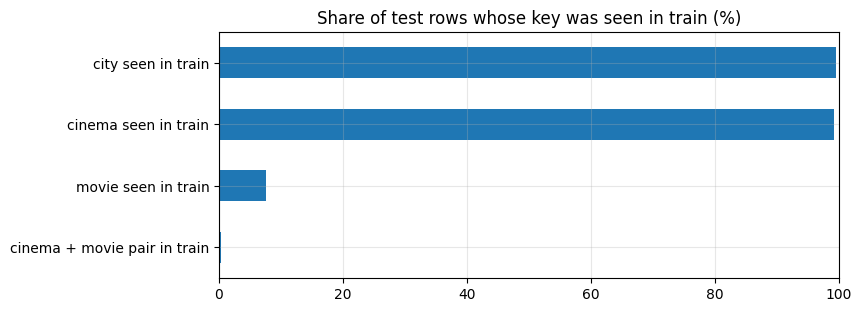

test cinemas not in train: ['2df461316312ad73a45a7b7354c24014', 'ab66df99207da01f3e300ef0163a1d2e', 'ea8d354888b056f56de16e2ce54e3415', 'f3432c52947b6412b4973fa6bf23d666']
test cities  not in train: ['MAGELANG', 'TUBAN']


In [18]:
# (b) How much of test is unseen in train?  (share of TEST ROWS)
train_pair = train[["cinema_ids", "movie_base"]].drop_duplicates().assign(seen=True)
pair_seen  = test[["cinema_ids", "movie_base"]].merge(train_pair, how="left", on=["cinema_ids", "movie_base"])["seen"].notna()

cold = pd.Series({
    "movie seen in train":           test.movie_base.isin(set(train.movie_base)).mean(),
    "cinema seen in train":          test.cinema_ids.isin(set(train.cinema_ids)).mean(),
    "city seen in train":            test.city_name.isin(set(train.city_name)).mean(),
    "cinema + movie pair in train":  pair_seen.mean(),
}) * 100

ax = cold.sort_values().plot.barh(figsize=(8, 3.2))
ax.set_title("Share of test rows whose key was seen in train (%)"); ax.set_xlim(0, 100)
plt.show()
print("test cinemas not in train:", sorted(set(test.cinema_ids) - set(train.cinema_ids)))
print("test cities  not in train:", sorted(set(test.city_name)  - set(train.city_name)))

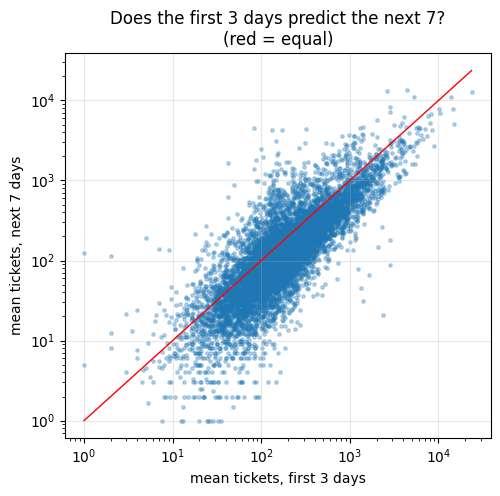

pairs used: 8886 | correlation of logs: 0.812


In [19]:
# (c) Imitate the test setup on train:  first 3 days of a pair  ->  next 7 days of the same pair
pair_first = train.groupby(keys).date_show.transform("min")
tt = train.assign(pair_first=pair_first)
tt = tt[tt.pair_first >= train.date_show.min() + pd.Timedelta(days=14)].copy()
tt["d"] = (tt.date_show - tt.pair_first).dt.days

first3 = tt[tt.d.between(0, 2)].groupby(keys).total_ticket.mean().rename("first3")
next7  = tt[tt.d.between(3, 9)].groupby(keys).total_ticket.mean().rename("next7")
ab = pd.concat([first3, next7], axis=1, join="inner")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(ab.first3, ab.next7, s=6, alpha=0.3)
lim = [ab.min().min(), ab.max().max()]; ax.plot(lim, lim, color="red", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("mean tickets, first 3 days"); ax.set_ylabel("mean tickets, next 7 days")
ax.set_title("Does the first 3 days predict the next 7?\n(red = equal)")
plt.show()
print("pairs used:", len(ab), "| correlation of logs:", round(np.log(ab.first3).corr(np.log(ab.next7)), 3))

**What you should see:** tickets **rise for roughly the first week, then decay** (about 290 on day 0, about 365 around day 7, about 120 by day 45; the right end of the curve rests on few rows). In test, only about **8% of rows** have a movie that appears in train, and only **0.3%** have an exact cinema + movie pair seen in train, while cinema and city are known for about 99%. The "first 3 days vs next 7 days" scatter follows the red line closely (log correlation around 0.8).

**Lessons**
- Treat test as a **cold-start** problem. Features that need a long train history for that exact pair will be empty. Features built from the **3 history days**, **cinema level**, **city level** and **movie metadata** will be filled.
- Part (c) is also your **blueprint for validation**: build windows on train that look like test (3 days known, then 7 to predict), and score on those. A random row split would leak and look too good.

## Stage 6: Movie metadata: how complete, and is there signal?

**What to do:** measure how many rows get movie information (raw title vs clean title), check what the external file really adds, then compare average demand by age rating and genre. Everything is **in memory only**.

**Watch out:** the two sources write genres differently (`Action, War` vs `Action|Adventure`), so we split them into lists before using them.

In [20]:
meta = movies[["movie_base", "age_rating", "genre"]].copy()
meta["genre_list"] = meta.genre.str.split(",").map(lambda xs: [x.strip() for x in xs])   # "Action, War" -> ["Action", "War"]

# 1) What does the external file add compared with movies.csv?
cmp = ext_meta[["movie_base", "age_rating", "genre"]].merge(
        movies[["movie_base", "age_rating", "genre"]], on="movie_base",
        suffixes=("_ext", "_movies"), validate="1:1")
print("external movies that are ALSO in movies.csv (clean title):", len(cmp), "of", len(ext_meta))
print("age_rating identical in both files:", (cmp.age_rating_ext == cmp.age_rating_movies).mean())
display(cmp[["movie_base", "genre_ext", "genre_movies"]].head(5))
print("\nmovies with an empty age_rating:", movies.loc[movies.age_rating.isna(), "original_title"].tolist())

# 2) Share of ticket rows that find a movie row, raw title vs clean title
cov = pd.DataFrame({
    "raw title":   {n: d.movie_title.isin(set(movies.original_title)).mean() * 100 for n, d in {"train": train, "test_history": test_hist, "test": test}.items()},
    "clean title": {n: d.movie_base.isin(set(meta.movie_base)).mean() * 100 for n, d in {"train": train, "test_history": test_hist, "test": test}.items()},
})
ax = cov.plot.bar(rot=0, figsize=(8, 3.5)); ax.set_ylim(0, 105)
ax.set_title("% of ticket rows that find their movie in movies.csv"); plt.show()

MergeError: Merge keys are not unique in left dataset; not a one-to-one merge

In [ ]:
# Movie-level view: average tickets per row for each movie (train only), joined to metadata
mt = train.groupby("movie_base").total_ticket.agg(mean_tix="mean", n_rows="size").reset_index()
mt = mt[mt.n_rows >= 50].merge(meta, on="movie_base", how="left", validate="1:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order = ["Semua Umur", "Remaja", "Dewasa", "Dewasa 21"]
data  = [np.log10(mt.loc[mt.age_rating == a, "mean_tix"]) for a in order]
axes[0].boxplot(data, tick_labels=[f"{a}\n(n={len(d)})" for a, d in zip(order, data)])
axes[0].set_title("Movie average tickets by age rating (log10)")

gx = mt.explode("genre_list").groupby("genre_list").mean_tix.agg(median="median", n="size")
gx = gx[gx.n >= 8].sort_values("median")
gx["median"].plot.barh(ax=axes[1])
for i, (m, n) in enumerate(zip(gx["median"], gx["n"])): axes[1].text(m, i, f" n={n}", va="center", fontsize=8)
axes[1].set_title("Median movie average tickets by genre (genres with 8+ movies)")
plt.tight_layout(); plt.show()

In [ ]:
# The external file has extra columns. How many movies actually have them?
extras = ["overview", "popularity", "runtime", "original_language", "release_year", "released", "imdb_id", "imdb_rating", "tmdb_id"]
all_titles = pd.concat([train.movie_base, test_hist.movie_base, test.movie_base]).nunique()
filled = ext_meta[extras].notna().sum().to_frame("movies with a value")
filled["out of all movies in ticket files"] = all_titles
filled

**What you should see:** with raw titles a visible share of rows finds no movie, with clean titles it is 100%. The external file agrees with `movies.csv` on age rating for all 15 movies and mainly gives **longer genre lists**. The 3 movies with an empty age rating are events (MLBB watch parties and a Twenty One Pilots film), and the external file does not cover them. In the charts, `Remaja` has the highest median (about 168 tickets per row per movie) and Action, Horror and Drama sit at the top of the genre chart while Romance and Family sit at the bottom. The extra external columns (popularity, runtime, release date...) exist for only **15 of 341 movies**, and `imdb_rating` is empty for all of them.

**Lessons**
- Use **age rating and genre** (as multi-label flags) as movie features. They exist for every movie once titles are cleaned. Treat the 3 event titles as their own case.
- **Do not** use popularity, runtime or release date as features: they are empty for about 96% of movies, and the 15 that have them are all recent releases, so the feature would simply mean "is a new release".
- Be honest about small groups: `Dewasa 21` has only 4 movies, and a genre with 8 or 10 movies can easily be noise.

## Stage 7: City and ticket price

**What to do:** look at price levels per city and compare them with average demand per city.

**Why:** the price table has 3 rows per city (Weekday, Friday, Weekend). We want to know if price carries information beyond "which city is this".

**Assumption to remember:** `day_tipe` in `holidays.csv` (weekday / friday / weekend) maps to `price_day` (Weekday / Friday / Weekend). Public holidays on a weekday are still labelled `weekday` in that file, so we assume they use the weekday price. The files do not confirm this.

In [ ]:
price_wide = prices.pivot(index="city_name", columns="price_day", values="ceil")[["Weekday", "Friday", "Weekend"]]
city = train.groupby("city_name").agg(mean_tix=("total_ticket", "mean"), cinemas=("cinema_ids", "nunique"))
city = city.join(price_wide, how="left")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

price_wide.Weekday.plot.hist(bins=15, ax=axes[0]); axes[0].set_title("Weekday price ceiling across 69 cities"); axes[0].set_xlabel("rupiah")

(price_wide.div(price_wide.Weekday, axis=0)[["Friday", "Weekend"]]).plot.box(ax=axes[1])
axes[1].set_title("Friday and Weekend price as multiple of Weekday")

axes[2].scatter(city.Weekday, city.mean_tix, s=city.cinemas * 12, alpha=0.5)
axes[2].set_xlabel("Weekday price ceiling"); axes[2].set_ylabel("mean tickets per row")
axes[2].set_title("City price vs demand (bubble = number of cinemas)")
plt.tight_layout(); plt.show()

print("correlation price vs mean tickets (cities):", round(city.Weekday.corr(city.mean_tix), 3))
print("price rows per city:", prices.groupby("city_name").size().unique())

In [ ]:
# Which cities carry the volume?  (concentration)
top = train.groupby("city_name").total_ticket.sum().sort_values(ascending=False)
share = (top.cumsum() / top.sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
top.head(15).sort_values().plot.barh(ax=axes[0]); axes[0].set_title("Top 15 cities by total tickets (train)")
share.reset_index(drop=True).plot(ax=axes[1]);     axes[1].set_title("Cumulative share of tickets by number of cities")
axes[1].set_xlabel("cities (largest first)"); axes[1].set_ylabel("% of all tickets")
plt.tight_layout(); plt.show()

**What you should see:** Friday prices are typically about 1.25x the Weekday price and Weekend about 1.33x, so the ratio is fairly stable. City price and city demand are only weakly related (correlation about 0.3), while the **number of cinemas in a city** relates more strongly to average tickets (about 0.5). The top 5 cities carry about 41% of tickets and the top 10 about 59%.

**Lessons**
- Price adds a day-type-specific number, so it can be a feature, but it mostly says "which city" and will overlap with city and cinema identity.
- Because a few cities dominate, check your validation score **per city group** later, not only overall.
- Train has 67 cities, test has 69 (Magelang and Tuban are new), and 4 test cinemas are new. Those rows need features that do not depend on train history for that cinema or city.

## Summary: what the EDA tells us to do next

| Finding | Decision for modelling |
|---|---|
| Test = 3 history days, then 7 days to predict, per pair | Build validation windows on train that copy this |
| Most test pairs and movies are unseen in train | Lean on history, cinema, city and movie metadata features |
| Raw titles do not match; clean titles do. `movies.csv` is then complete | Always join through `movie_base`, and count unmatched keys after every join |
| Train has missing days, test does not; zero never appears | Test "gaps = 0" vs "leave gaps" on validation |
| Target is very skewed and has weekday/holiday/format effects | Use log target, calendar features, format feature |
| `total_show` and `occupation_rate` are not in test | Use only as past (history) information |
| External file covers only 15 movies and mostly duplicates `movies.csv` | Use age rating and genre. Skip popularity, runtime, release date |
| 4 test cinemas and 2 test cities are new | Features need fallbacks (city or national averages) |

**Next notebook stage (when you are ready):** build the validation set, then the first baseline (e.g. repeat the mean of the last 3 days) so every later model has a score to beat.

## Stage 8: Abnormal days (the early June drop)

**What to do**: Build one row per calendar day. Count rows, cinemas, movies, shows and tickets. Flag days that look far below the usual level.

**Why**: A day can look low because people stayed home, or because data is missing. Those are different problems, and a model should not treat them the same way.

**What to look for**: Which days get red flags, and whether the flags match what you already found (1 to 5 June, then 7, 9, 10 and 11 June).

In [ ]:
# --- settings you can change ---
WINDOW      = 29     # days used to find the "usual" level
FEW_CINEMAS = 0.80   # flag if cinemas are below 80% of usual
FEW_SHOWS   = 0.65   # flag if shows per row are below 65% of usual

# one row per date, built from train
daily = train.groupby("date_show").agg(
    rows=("total_ticket", "size"),
    cinemas=("cinema_ids", "nunique"),
    movies=("movie_title", "nunique"),
    total_show=("total_show", "sum"),
    tickets=("total_ticket", "sum"),
)

# add calendar days that have no rows at all (they would be invisible otherwise)
all_days = pd.date_range(train.date_show.min(), train.date_show.max(), freq="D")
daily = daily.reindex(all_days).rename_axis("date_show")
print("calendar days with no rows at all:", int(daily.rows.isna().sum()))
count_cols = ["rows", "cinemas", "movies", "total_show", "tickets"]
daily[count_cols] = daily[count_cols].fillna(0)

# per-row measures (a day with 0 rows gets NaN, not a fake number)
daily["shows_per_row"]   = daily.total_show / daily.rows.replace(0, np.nan)
daily["tickets_per_row"] = daily.tickets    / daily.rows.replace(0, np.nan)

# "usual" level = median of the 29 days around each day (centered)
def usual(s):
    return s.rolling(WINDOW, center=True, min_periods=7).median()

daily["cinemas_usual"] = usual(daily.cinemas)
daily["shows_usual"]   = usual(daily.shows_per_row)
daily["cinemas_ratio"] = daily.cinemas / daily.cinemas_usual
daily["shows_ratio"]   = daily.shows_per_row / daily.shows_usual

# the two flags
daily["few_cinemas"] = daily.cinemas_ratio < FEW_CINEMAS
daily["few_shows"]   = daily.shows_ratio   < FEW_SHOWS
daily["flag_type"] = np.select(
    [daily.few_cinemas & daily.few_shows, daily.few_cinemas, daily.few_shows],
    ["both", "few cinemas", "few shows per row"],
    default="ok",
)

# small table of flagged days (in memory only)
flagged = daily[daily.flag_type != "ok"]
cols = ["rows", "cinemas", "cinemas_usual", "shows_per_row", "shows_usual", "tickets_per_row", "flag_type"]
print(len(flagged), "flagged days out of", len(daily), "\n")
display(flagged[cols].round(1))

NameError: name 'train' is not defined